In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
superstore=pd.read_csv('/content/drive/MyDrive/Dataset/Sample - Superstore.csv',encoding='latin1')

In [ ]:
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
superstore.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# **PRODUCT SALES**

In [ ]:
superstore['Product Name'].unique()

array(['Bush Somerset Collection Bookcase',
       'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back',
       'Self-Adhesive Address Labels for Typewriters by Universal', ...,
       'Eureka Hand Vacuum, Bagless', 'LG G2',
       'Eldon Jumbo ProFile Portable File Boxes Graphite/Black'],
      dtype=object)

In [ ]:
s=superstore.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(5).reset_index()

In [ ]:
ss=superstore.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

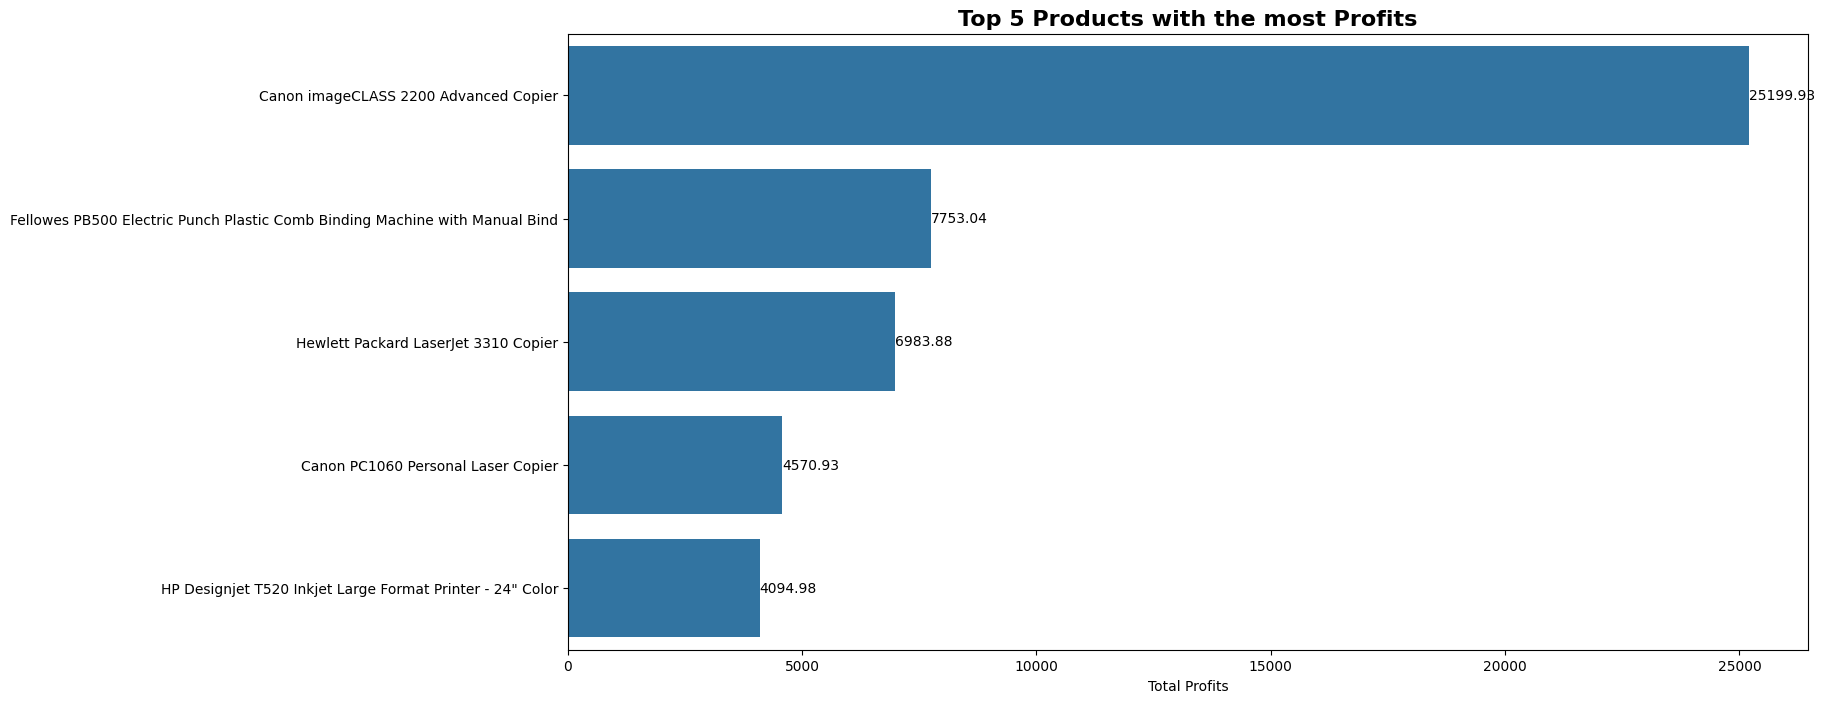

In [ ]:
plt.figure(figsize=(16,8))
sns.barplot(x='Profit',y='Product Name',data=s)
plt.title('Top 5 Products with the most Profits',fontsize=16,weight='bold')
plt.ylabel('')
plt.xlabel('Total Profits')
for i,v in enumerate(s['Profit']):
  plt.text(v,i,str(round(v,2)),va='center')
plt.savefig('product_profit.jpg',bbox_inches='tight')
plt.show()

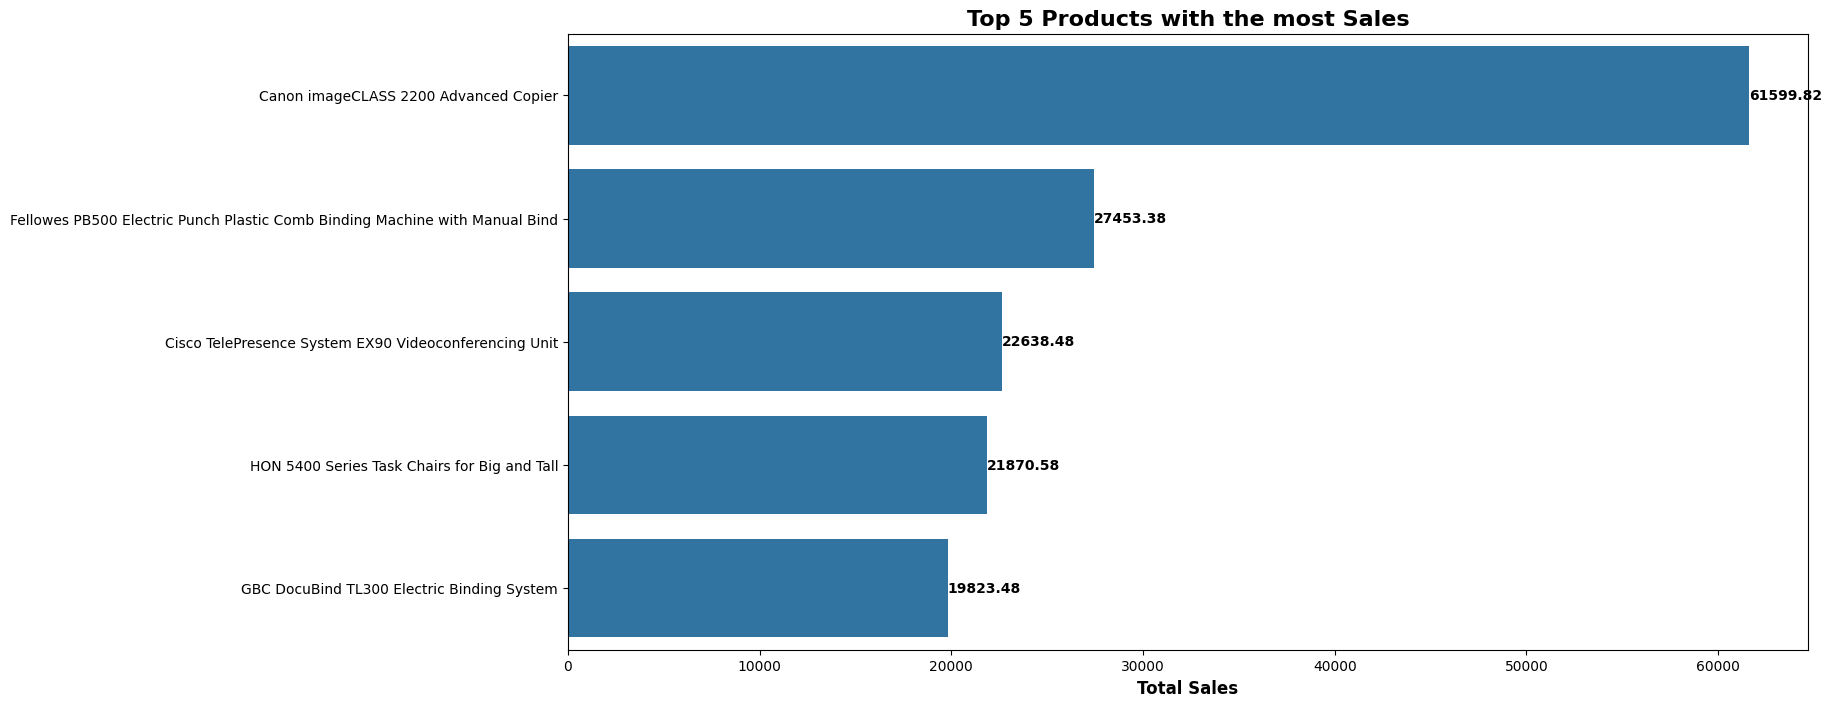

In [ ]:
from matplotlib import colors
plt.figure(figsize=(16,8))
sns.barplot(x='Sales',y='Product Name',data=ss)
plt.title('Top 5 Products with the most Sales',fontsize=16,weight='bold')
plt.ylabel('')
plt.xlabel('Total Sales',fontsize=12,weight='bold')
for i,v in enumerate(ss['Sales']):
  plt.text(v,i,str(round(v,2)),va='center',weight='bold')
plt.savefig('product_sales.jpg',bbox_inches='tight')
plt.show()

In [ ]:
b=superstore.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

In [ ]:
bb=superstore.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()

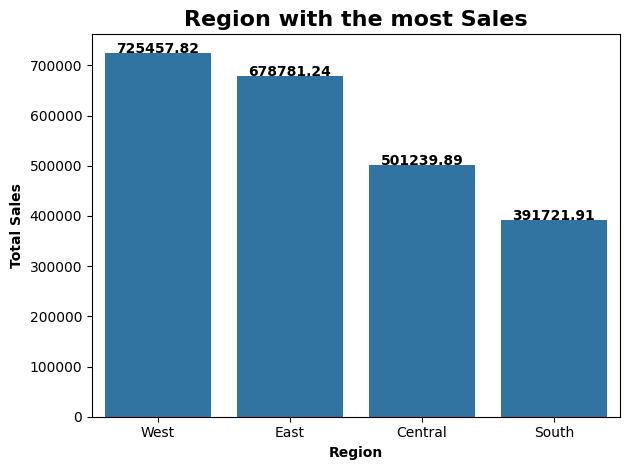

In [ ]:
sns.barplot(x='Region',y='Sales',data=b)
plt.title('Region with the most Sales',fontsize=16,weight='bold')
plt.xlabel('Region',weight='bold')
plt.ylabel('Total Sales',weight='bold')
plt.tight_layout()
for i,v in enumerate(b['Sales']):
  plt.text(i,v+0.01,str(round(v,2)),ha='center',weight='bold')
plt.savefig('salesbyregion.jpg',bbox_inches='tight')
plt.show()

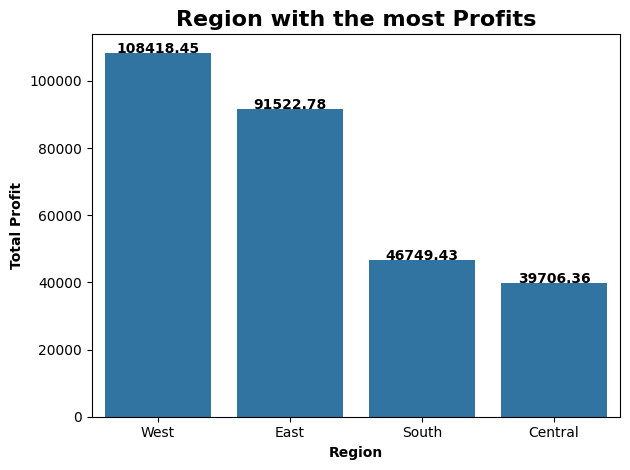

In [ ]:
sns.barplot(x='Region',y='Profit',data=bb)
plt.title('Region with the most Profits',fontsize=16,weight='bold')
plt.xlabel('Region',weight='bold')
plt.ylabel('Total Profit',weight='bold')
plt.tight_layout()
for i,v in enumerate(bb['Profit']):
  plt.text(i,v+0.01,round(v,2),ha='center',weight='bold')
plt.savefig('profitbyregion.jpg',bbox_inches='tight')
plt.show()

In [ ]:
c=superstore.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

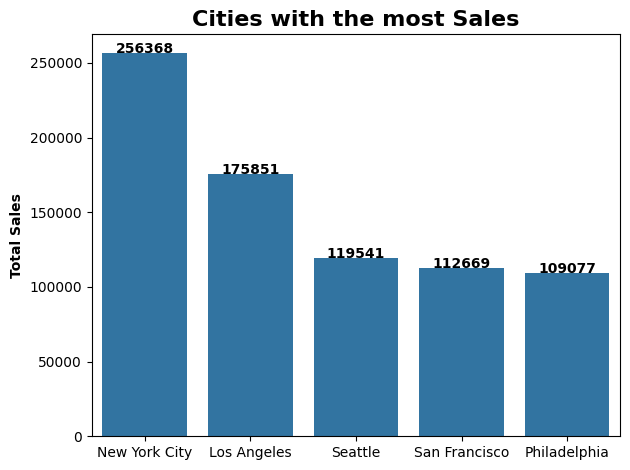

In [ ]:
sns.barplot(x='City',y='Sales',data=c)
plt.title('Cities with the most Sales',fontsize=16,weight='bold')
plt.xlabel('')
plt.ylabel('Total Sales',weight='bold')
plt.tight_layout()
for i,v in enumerate(c['Sales']):
  plt.text(i,v+0.01,str(round(v)),ha='center',weight='bold')
plt.savefig('salesbycity.jpg',bbox_inches='tight')
plt.show()

In [ ]:
d=superstore.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

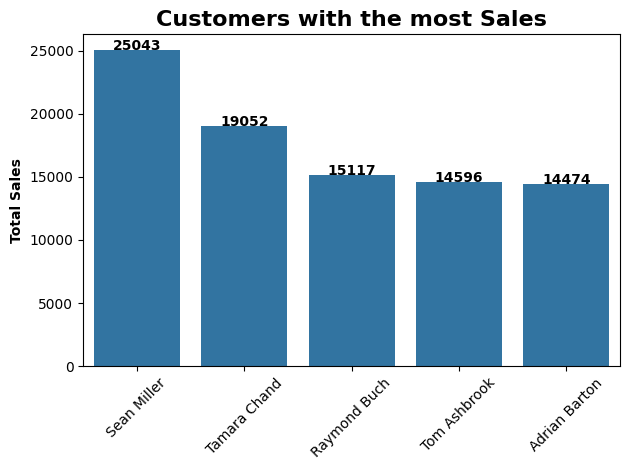

In [ ]:
sns.barplot(x='Customer Name',y='Sales',data=d)
plt.title('Customers with the most Sales',fontsize=16,weight='bold')
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('Total Sales',weight='bold')
plt.tight_layout()
for i,v in enumerate(d['Sales']):
  plt.text(i,v+0.01,str(round(v)),ha='center',weight='bold')
plt.savefig('salesbycustomer.jpg',bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Most used shipment mode')

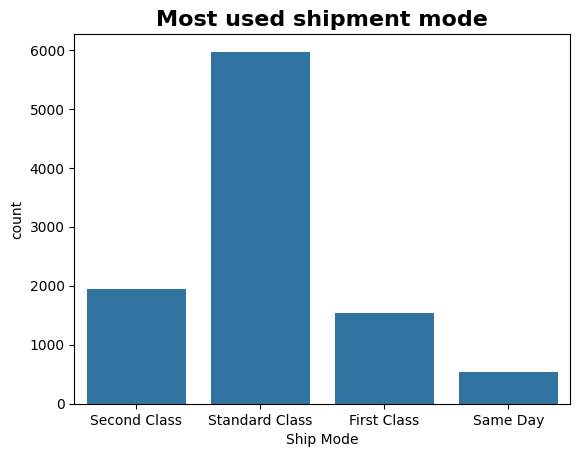

In [ ]:
sns.countplot(x='Ship Mode',data=superstore)
plt.title('Most used shipment mode',fontsize=16,weight='bold')

Text(0.5, 1.0, 'Most ordered category')

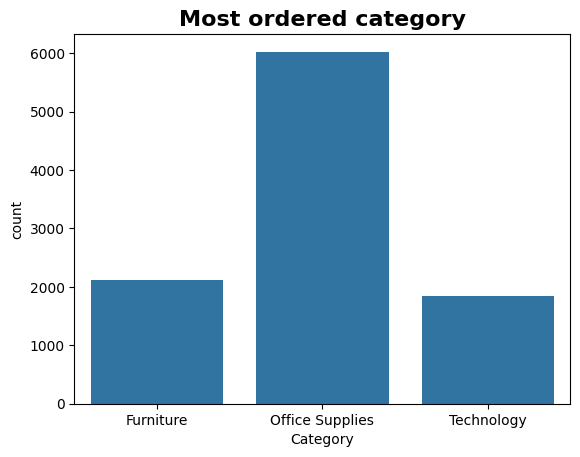

In [ ]:
sns.countplot(x='Category',data=superstore)
plt.title('Most ordered category',fontsize=16,weight='bold')

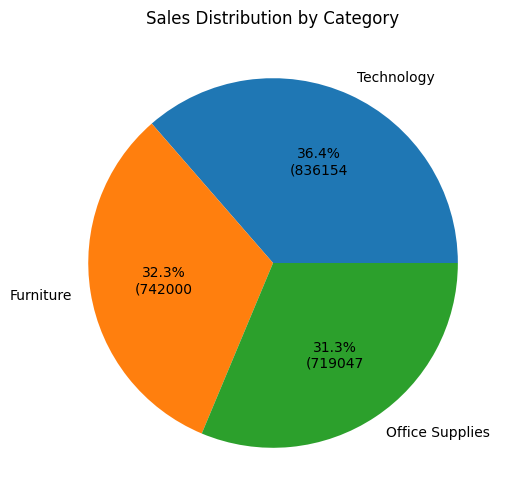

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    e['Sales'],
    labels=e['Category'],
    autopct=lambda p: f'{p:.1f}%\n({p * sum(e["Sales"]) / 100:.0f}')


plt.title('Sales Distribution by Category')
plt.savefig('sales_category.jpg',bbox_inches='tight')
plt.show()

In [ ]:
e=superstore.groupby('Category')['Sales'].sum().head().sort_values(ascending=False).reset_index()
e

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


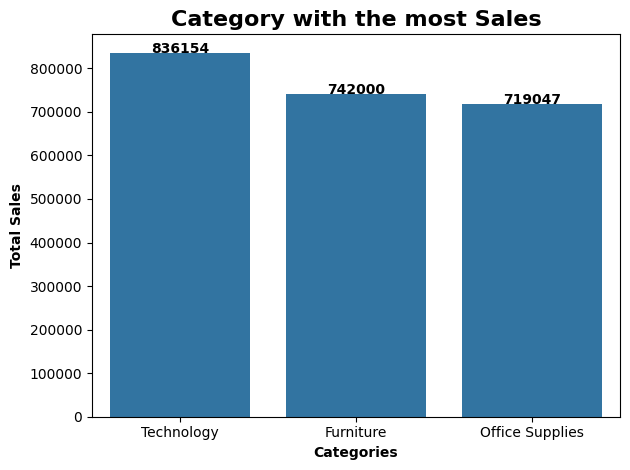

In [ ]:
sns.barplot(x='Category',y='Sales',data=e)
plt.title('Category with the most Sales',fontsize=16,weight='bold')
plt.xlabel('Categories',weight='bold')
plt.ylabel('Total Sales',weight='bold')
plt.tight_layout()
for i,v in enumerate(e['Sales']):
  plt.text(i,v+0.01,str(round(v)),ha='center',weight='bold')
plt.savefig('salesbyCategory.jpg',bbox_inches='tight')
plt.show()

In [ ]:
s=superstore

In [ ]:
s['Order Date']=pd.to_datetime(s['Order Date'])

In [ ]:
s['Year']=s['Order Date'].dt.year

In [ ]:
yearly_sales=s.groupby('Year')['Sales'].sum().reset_index()
yearly_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


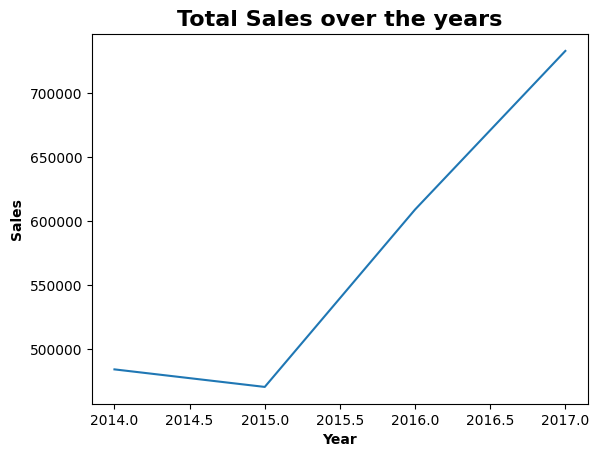

In [ ]:
sns.lineplot(y='Sales',x='Year',data=yearly_sales)
plt.title('Total Sales over the years',fontsize=16,weight='bold')
plt.xlabel('Year',weight='bold')
plt.ylabel('Sales',weight='bold')
plt.savefig('salesyear.jpg',bbox_inches='tight')

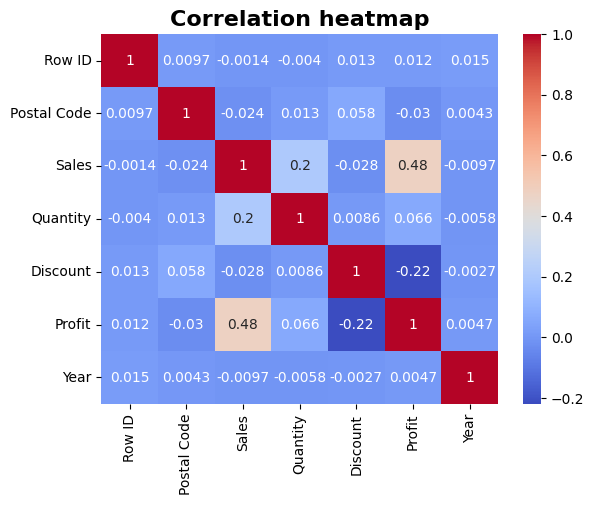

In [ ]:
corr=superstore.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation heatmap',fontsize=16,weight='bold')
plt.savefig('corr.jpg',bbox_inches='tight')

<Axes: xlabel='Sales', ylabel='Profit'>

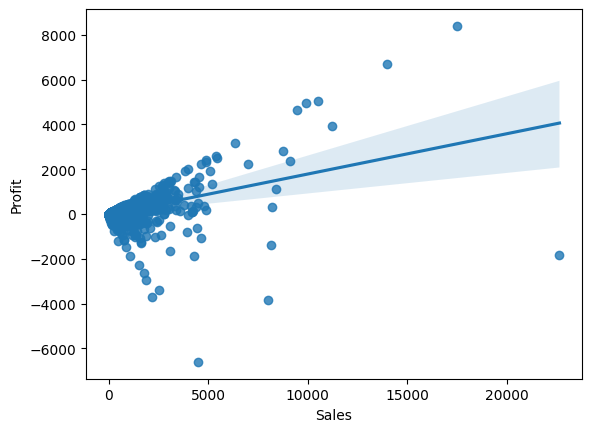

In [ ]:
sns.regplot(x='Sales',y='Profit',data=superstore)